# Tokenización y Representaciones Vectoriales en LLMs

## ¿Qué es la tokenización?

Antes de que un modelo de lenguaje como GPT o BERT pueda procesar texto, necesita convertir las palabras (o partes de palabras) en números. Este proceso se llama **tokenización**.

Un **token** es la unidad básica de texto que el modelo "ve". Puede ser:
- Una palabra completa: `"perro"` → token
- Un subpalabra: `"tokenización"` → `["token", "ización"]`
- Un carácter individual

## ¿Qué es un embedding (representación vectorial)?

Una vez tokenizado el texto, cada token se mapea a un **vector de números reales** en un espacio de alta dimensión. Este vector es el *embedding* del token.

**¿Por qué vectores?** Porque nos permiten representar el *significado semántico* de las palabras de forma matemática. Palabras con significados similares quedan **cerca** en este espacio vectorial.

```
"rey"   → [0.23, -0.81, 0.45, ..., 0.12]  (300 números)
"reina" → [0.21, -0.79, 0.48, ..., 0.15]  (300 números, ¡muy similar!)
"mesa"  → [-0.54, 0.33, -0.12, ..., 0.87] (300 números, muy diferente)
```

En este notebook usaremos **Word2Vec** (Google News), un modelo clásico entrenado sobre millones de artículos de noticias, para explorar estas representaciones.

## Paso 1 — Instalar dependencias

`gensim` es una librería de Python especializada en modelos de lenguaje y representaciones vectoriales. La usaremos para cargar modelos Word2Vec pre-entrenados sin necesidad de entrenar desde cero.

In [1]:
# gensim ya instalado en el entorno local
# !pip install gensim

## Paso 2 — Cargar el modelo Word2Vec

Cargamos el modelo `word2vec-google-news-300`, entrenado por Google sobre ~100 mil millones de palabras de artículos de noticias.

- Contiene ~3 millones de palabras/frases en su vocabulario
- Cada token está representado por un vector de **300 dimensiones**

> **Nota:** La primera vez esto descarga ~1.6 GB. Después queda en caché local.

In [2]:
import gensim.downloader as api

# Load pre-trained Word2Vec model
model = api.load("word2vec-google-news-300")

## Paso 3 — ¿Cuántas dimensiones tiene un embedding?

Verifiquemos la dimensión del vector de la palabra `"apple"`. Cada token en este modelo está representado como un punto en un espacio de **300 dimensiones**.

Aunque 300 dimensiones es imposible de visualizar directamente, podemos usar técnicas de reducción dimensional como **PCA** (Análisis de Componentes Principales) o **t-SNE** para proyectarlos en 2D o 3D y así visualizar las relaciones semánticas entre palabras.

In [3]:
len(model['apple'])

300

## Paso 4 — Aritmética vectorial: la magia de los embeddings

Una de las propiedades más fascinantes de los embeddings es que **las relaciones semánticas se preservan como operaciones vectoriales**.

El experimento clásico es:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

¿Qué significa esto? El vector que va de `"man"` a `"king"` (la *dirección de realeza*) es aproximadamente el mismo que el que va de `"woman"` a `"queen"`. El modelo aprendió este concepto implícitamente al leer millones de textos — **nadie le enseñó explícitamente qué es un rey o una reina**.

### Visualización con PCA 3D

Como no podemos graficar 300 dimensiones, usamos **PCA** para reducir a 3D, buscando las tres direcciones que capturan la mayor varianza. Las líneas rojas y azules muestran la similitud coseno entre el vector resultado y `king`/`queen`.

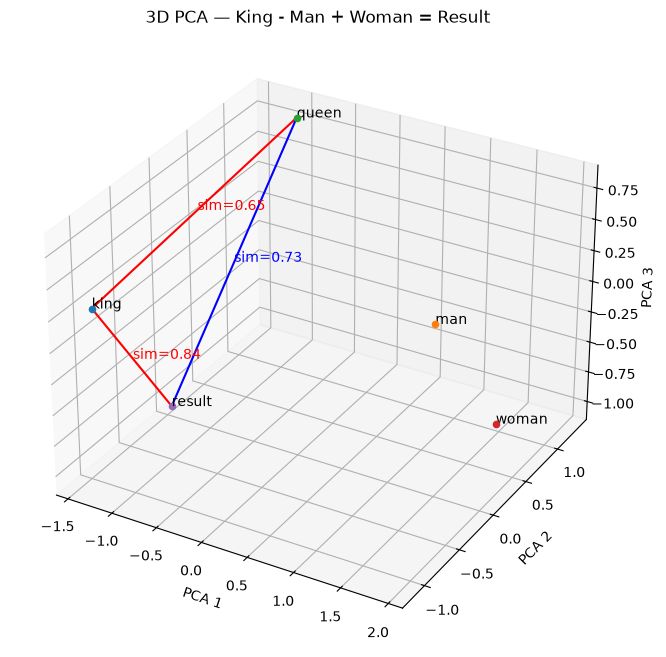

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


v_king = model['king']
v_man = model['man']
v_woman = model['woman']
v_queen = model['queen']
v_result = v_king - v_man + v_woman


words_to_plot = ['king', 'man', 'queen', 'woman', 'result']
vectors_to_plot = [v_king, v_man, v_queen, v_woman, v_result]

pca = PCA(n_components=3)
reduced = pca.fit_transform(vectors_to_plot)
coords = {word: reduced[i] for i, word in enumerate(words_to_plot)}

def cos(a, b):
    return cosine_similarity([a], [b])[0, 0]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for word, vec in coords.items():
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], word)

result = coords['result']
king = coords['king']
queen = coords['queen']

# Result ↔ King
ax.plot([result[0], king[0]], [result[1], king[1]], [result[2], king[2]], color='red')
mid_rk = (result + king) / 2.0
ax.text(mid_rk[0], mid_rk[1], mid_rk[2],
        f"sim={cos(v_result, v_king):.2f}", color='red')

# King ↔ Queen
ax.plot([king[0], queen[0]], [king[1], queen[1]], [king[2], queen[2]], color='red')
mid_kq = (king + queen) / 2.0
ax.text(mid_kq[0], mid_kq[1], mid_kq[2],
        f"sim={cos(v_king, v_queen):.2f}", color='red')

# Result ↔ Queen
ax.plot([result[0], queen[0]], [result[1], queen[1]], [result[2], queen[2]], color='blue')
mid_rq = (result + queen) / 2.0
ax.text(mid_rq[0], mid_rq[1], mid_rq[2],
        f"sim={cos(v_result, v_queen):.2f}", color='blue')

ax.set_title("3D PCA — King - Man + Woman = Result")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
plt.show()

## Paso 5 — ¿A qué palabras se parece el resultado?

Ahora buscamos los 10 tokens más similares al vector resultado de `king - man + woman` usando **similitud coseno**.

La similitud coseno mide el ángulo entre dos vectores en el espacio de embeddings:
- `sim = 1.0` → misma dirección (palabras idénticas o sinónimos perfectos)
- `sim ≈ 0.7` → fuertemente relacionadas
- `sim ≈ 0.0` → sin relación semántica

Si los embeddings capturaron bien la semántica, deberíamos ver `"queen"` entre los primeros resultados — y de hecho aparece en el segundo lugar.

In [5]:
similar_words = model.most_similar(positive=[v_result], topn=10)

print("Top 10 palabras mas similares a la operación 'king - man + woman':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'king - man + woman':
king: 0.8449
queen: 0.7301
monarch: 0.6455
princess: 0.6156
crown_prince: 0.5819
prince: 0.5777
kings: 0.5614
sultan: 0.5377
Queen_Consort: 0.5344
queens: 0.5290


### Vecinos más cercanos de `"queen"`

Para comparar, veamos directamente los 10 tokens más similares a `"queen"`. Esto nos dice qué conceptos el modelo asocia con ser reina. Observa que `king` aparece como vecino de `queen` y viceversa — los embeddings capturaron la relación bidireccional entre estos conceptos.

In [6]:
similar_words = model.most_similar(positive=[v_queen], topn=10)

print("Top 10 palabras mas similares a la operación 'queen':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'queen':
queen: 1.0000
queens: 0.7399
princess: 0.7071
king: 0.6511
monarch: 0.6384
very_pampered_McElhatton: 0.6357
Queen: 0.6163
NYC_anglophiles_aflutter: 0.6061
Queen_Consort: 0.5924
princesses: 0.5908


### Vecinos más cercanos de `"king"`

Finalmente, los 10 tokens más similares a `"king"`. Compara los vecinos de `king` vs. los de `queen`: ¿son simétricos? ¿Hay sesgos del corpus de entrenamiento que puedas identificar?

In [7]:
similar_words = model.most_similar(positive=[v_king], topn=10)

print("Top 10 palabras mas similares a la operación 'king':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'king':
king: 1.0000
kings: 0.7138
queen: 0.6511
monarch: 0.6413
crown_prince: 0.6204
prince: 0.6160
sultan: 0.5865
ruler: 0.5798
princes: 0.5647
Prince_Paras: 0.5433


---
## Reto: Explora tu propio espacio semántico

Ahora es tu turno. Usando el modelo Word2Vec que ya cargamos, realiza las siguientes exploraciones:

### Parte 1 — Tu animal favorito
1. Elige tu animal favorito en inglés (e.g., `"dolphin"`, `"tiger"`, `"eagle"`)
2. Obtén su vector: `v_animal = model["nombre_del_animal"]`
3. Busca los 10 tokens más similares
4. ¿Los resultados tienen sentido semántico? ¿Encuentras tokens sorprendentes?

### Parte 2 — Operaciones vectoriales
Diseña operaciones análogas a `king - man + woman` con tu animal:
- `"dog" - "domestic" + "wild"` → ¿a qué llega?
- `"eagle" - "fly" + "swim"` → ¿qué predice el modelo?
- Inventa tu propia operación semántica y explica qué esperabas y qué obtuviste

### Parte 3 — Visualización
Toma tu animal, sus vecinos más cercanos y alguna operación vectorial, y grafícalos en 3D con PCA igual que hicimos arriba. ¿Forman clusters semánticos con sentido?

> **Tip:** Si una palabra no está en el vocabulario, el modelo lanzará un `KeyError`. Verifica con `"palabra" in model.key_to_index` antes de usarla.

### Parte 1 — Mi animal: el jaguar

Elegí `jaguar` porque es el felino emblemático de Colombia y porque es una palabra **ambigua** en inglés (animal y marca de carros de lujo), lo que la vuelve interesante para ver qué aprendió un modelo entrenado con noticias.

In [8]:
mi_animal = "jaguar"
assert mi_animal in model.key_to_index
v_animal = model[mi_animal]
print(f"Dimensión del vector de '{mi_animal}': {len(v_animal)}\n")
print(f"Top 10 palabras más similares a '{mi_animal}':")
vecinos = model.most_similar(positive=[v_animal], topn=11)[1:]   # el primero es la propia palabra
for word, sim in vecinos:
    print(f"  {word:22s} {sim:.4f}")

print("\nMismo análisis con la forma capitalizada 'Jaguar' (típica de la marca):")
for word, sim in model.most_similar("Jaguar", topn=10):
    print(f"  {word:22s} {sim:.4f}")

Dimensión del vector de 'jaguar': 300

Top 10 palabras más similares a 'jaguar':


  jaguars                0.6738
  Macho_B                0.6313
  panther                0.6086
  lynx                   0.5815
  rhino                  0.5754
  lizard                 0.5607
  tapir                  0.5563
  tiger                  0.5529
  leopard                0.5473
  Florida_panther        0.5464

Mismo análisis con la forma capitalizada 'Jaguar' (típica de la marca):


  Land_Rover             0.6484
  Aston_Martin           0.6437
  Mercedes               0.6420
  Porsche                0.6233
  BMW                    0.6055
  Bentley_Arnage         0.6040
  XF_sedan               0.5996
  Audi                   0.5976
  Jaguar_XF              0.5951
  XJ_saloon              0.5942


**Análisis — Parte 1.** Sí tiene sentido, y además mostró algo que no esperaba:

- `jaguar` en minúscula es el animal: sus vecinos son `panther`, `lynx`, `tiger`, `leopard` y `Florida_panther`. Salen incluso `tapir` y `lizard`, que no son felinos pero comparten hábitat en noticias sobre fauna de América.
- **Lo sorprendente:** `Macho_B` (0.63) es el segundo vecino. Así se llamaba el último jaguar salvaje conocido en Estados Unidos, y su captura en 2009 salió en todos los noticieros. El modelo no aprendió zoología; aprendió de lo que hablaban las noticias.
- `Jaguar` con mayúscula es otro "token" y otro significado: la marca de carros (`Land_Rover`, `Aston_Martin`, `Porsche`, `Jaguar_XF`). Word2Vec asigna **un vector por forma escrita**, así que la mayúscula funciona como desambiguador gratis. Un LLM moderno lo resolvería con el contexto de la frase; Word2Vec no puede, porque no tiene contexto.

### Parte 2 — Operaciones vectoriales

In [9]:
def analogia(positivas, negativas, topn=5, titulo=None):
    faltan = [w for w in positivas + negativas if w not in model.key_to_index]
    if faltan:
        print(f"Fuera de vocabulario: {faltan}"); return
    print(titulo or f"{' + '.join(positivas)} - {' - '.join(negativas)}")
    for word, sim in model.most_similar(positive=positivas, negative=negativas, topn=topn):
        print(f"  {word:22s} {sim:.4f}")
    print()

analogia(["dog", "wild"], ["domestic"], titulo="dog - domestic + wild")
analogia(["eagle", "swim"], ["fly"], titulo="eagle - fly + swim")
# Mis propias operaciones
analogia(["jaguar", "Africa"], ["Colombia"], titulo="jaguar - Colombia + Africa   (¿el 'jaguar' de África?)")
analogia(["jaguar", "animal"], ["car"], titulo="jaguar - car + animal   (quitar el sentido de marca)")
analogia(["kitten", "dog"], ["cat"], titulo="kitten - cat + dog   (relación cría ↔ adulto)")

dog - domestic + wild


  cat                    0.5444
  dogs                   0.5418
  leashless              0.5386
  bichon_frises          0.5319
  coyote                 0.5306

eagle - fly + swim


  swimming               0.5138
  foot_putt              0.4851
  birdie                 0.4840
  foot_birdie_putt       0.4702
  birdie_putt            0.4663

jaguar - Colombia + Africa   (¿el 'jaguar' de África?)


  rhino                  0.5417
  antelopes              0.4912
  Grevy_zebra            0.4868
  antelope               0.4830
  cheetah                0.4799

jaguar - car + animal   (quitar el sentido de marca)


  animals                0.6001
  jaguars                0.5472
  mammal                 0.5375
  Animal                 0.5309
  panther                0.5308

kitten - cat + dog   (relación cría ↔ adulto)


  puppy                  0.7700
  pup                    0.6862
  pit_bull               0.6777
  dogs                   0.6771
  Rottweiler             0.6647



**Análisis — Parte 2.**

| Operación | Esperaba | Obtuve | Lectura |
|---|---|---|---|
| `dog − domestic + wild` | wolf / coyote | `cat`, `dogs`, … `coyote` (5.º) | Casi: `coyote` aparece, pero los primeros son otras mascotas. "Domestic/wild" no es un eje tan limpio como "man/woman". |
| `eagle − fly + swim` | un ave acuática o un pez | `swimming`, `birdie`, `birdie_putt` | Falla divertida: en noticias, `eagle` y `birdie` son jugadas de **golf**. El sesgo del corpus le gana a la biología. |
| `jaguar − Colombia + Africa` | leopardo / guepardo | `rhino`, `antelope`, `zebra`, `cheetah` | Captura la región (fauna africana) y llega a `cheetah`, el felino africano, en 5.º lugar. |
| `jaguar − car + animal` | reforzar el sentido animal | `animals`, `jaguars`, `mammal`, `panther` | Funciona: la similitud coseno con `jaguar` sube a 0.835, con `Jaguar` (la marca) cae a 0.055 y con `BMW` es −0.107. |
| `kitten − cat + dog` | puppy | **`puppy` (0.77)** | La analogía más limpia: la relación cría ↔ adulto sí es un eje lineal en el espacio. |

Nota sobre la celda de *king − man + woman*: el primer resultado es `king` y no `queen` porque `most_similar(positive=[v_result])` no excluye las palabras de entrada. Con `most_similar(positive=["king", "woman"], negative=["man"])`, gensim sí las excluye y `queen` sale primera.

### Parte 3 — Visualización 3D con PCA

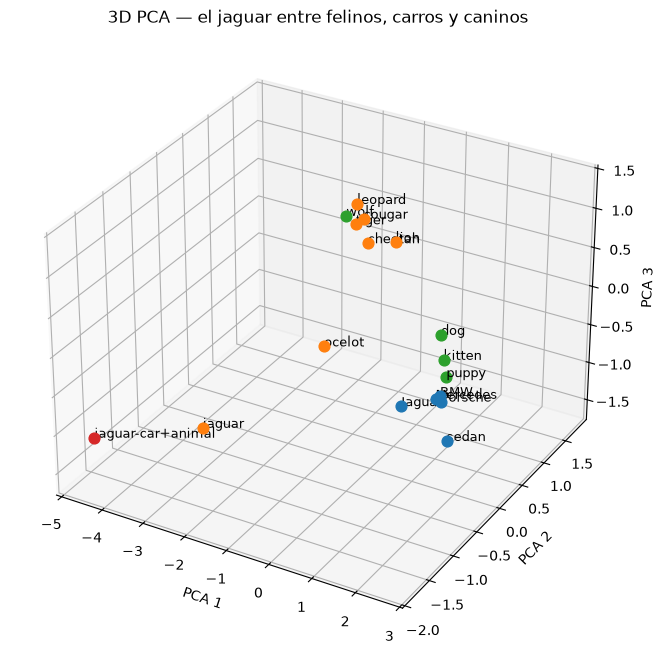

cos(jaguar-car+animal, jaguar  ) = 0.835
cos(jaguar-car+animal, leopard ) = 0.495
cos(jaguar-car+animal, Jaguar  ) = 0.055
cos(jaguar-car+animal, BMW     ) = -0.107


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

grupos = {
    "felinos":  ["jaguar", "leopard", "cheetah", "tiger", "lion", "cougar", "ocelot"],
    "carros":   ["Jaguar", "BMW", "Porsche", "Mercedes", "sedan"],
    "caninos":  ["dog", "wolf", "puppy", "kitten"],
}
v_op = model["jaguar"] - model["car"] + model["animal"]
palabras, vectores, colores = [], [], []
paleta = {"felinos": "tab:orange", "carros": "tab:blue", "caninos": "tab:green"}
for g, ws in grupos.items():
    for w in ws:
        if w in model.key_to_index:
            palabras.append(w); vectores.append(model[w]); colores.append(paleta[g])
palabras.append("jaguar-car+animal"); vectores.append(v_op); colores.append("tab:red")

reduced = PCA(n_components=3, random_state=0).fit_transform(vectores)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for (x, y, z), w, c in zip(reduced, palabras, colores):
    ax.scatter(x, y, z, color=c, s=60)
    ax.text(x, y, z, w, fontsize=9)
ax.set_title("3D PCA — el jaguar entre felinos, carros y caninos")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
plt.show()

from sklearn.metrics.pairwise import cosine_similarity
for w in ["jaguar", "leopard", "Jaguar", "BMW"]:
    print(f"cos(jaguar-car+animal, {w:8s}) = {cosine_similarity([v_op], [model[w]])[0,0]:.3f}")

**Análisis — Parte 3.** Hay clusters, pero no exactamente los que esperaba, y eso es lo interesante:

- **Felinos grandes** (`leopard`, `tiger`, `cougar`, `cheetah`, `lion`) forman un grupo compacto arriba. Se les cuela `wolf`, que en noticias aparece en el mismo contexto de "depredador salvaje".
- **Marcas de carros** (`BMW`, `Porsche`, `Mercedes`, `Jaguar` con mayúscula, `sedan`) forman otro grupo abajo a la derecha. Muy cerca quedan los **caninos domésticos** (`dog`, `puppy`, `kitten`): en 3 componentes de PCA, "mascota de casa" y "producto de consumo" terminan en la misma región.
- **`jaguar` (el animal) queda aislado a la izquierda**, lejos de los demás felinos. Su vector mezcla dos mundos (animal y la sombra de la marca), y PCA dedica justamente su primer componente a separarlo. `ocelot`, un felino pequeño y poco mencionado, también queda suelto.
- El vector **`jaguar − car + animal` (rojo)** cae pegado a `jaguar` y en el extremo opuesto a las marcas. Es coherente con las similitudes medidas: 0.835 con `jaguar`, 0.055 con `Jaguar` y −0.107 con `BMW`. La resta sí alejó el vector de los carros, pero no lo llevó al centro de los felinos: le quitó "carro", no le agregó "felino".

**Conclusión.** Word2Vec convierte relaciones semánticas en geometría, pero hereda el mundo de su corpus: sabe más de golf y de un jaguar famoso de Arizona que de biología, y una palabra ambigua queda "entre dos aguas" en el espacio. Esa es la limitación que los embeddings **contextuales** de los Transformers vienen a resolver. (Ojo: PCA a 3D conserva solo parte de la varianza de 300 dimensiones, así que las distancias del gráfico son orientativas; las similitudes coseno de arriba son la medida exacta.)